In [4]:
import pandas as pd, numpy as np

df = pd.read_csv('../data/raw/ecommerce_sales_analytics_5000-selected-columns.csv', sep=';')
df.columns = df.columns.str.strip()

df['unit_price'] = (df['unit_price'].astype(str).str.strip()
                     .str.replace(',', '.', regex=False).astype(float))
df['discount'] = (df['discount'].astype(str).str.strip()
                   .replace('-', np.nan).astype(float))
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%Y')
df['total_value'] = df['quantity'] * df['unit_price'] * (1 - df['discount'].fillna(0))

In [7]:
# conferir se sobrou algum problema
print(df.isna().sum())

order_id             0
order_date           0
customer_id          0
product_category     0
region               0
quantity             0
unit_price           0
discount            68
payment_method       0
delivery_days        0
total_value          0
dtype: int64


In [8]:
# ver as primeiras linhas já tratadas
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,total_value
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,1883.1960
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,304.1038
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,644.3496
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,2569.9030
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,468.5645


In [10]:
df.to_csv('../data/processed/dados_limpos.csv', index=False)

C:\Users\julia\AppData\Local\Temp\ipykernel_37036\1345300688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=receita_categoria.values, y=receita_categoria.index, palette='viridis')


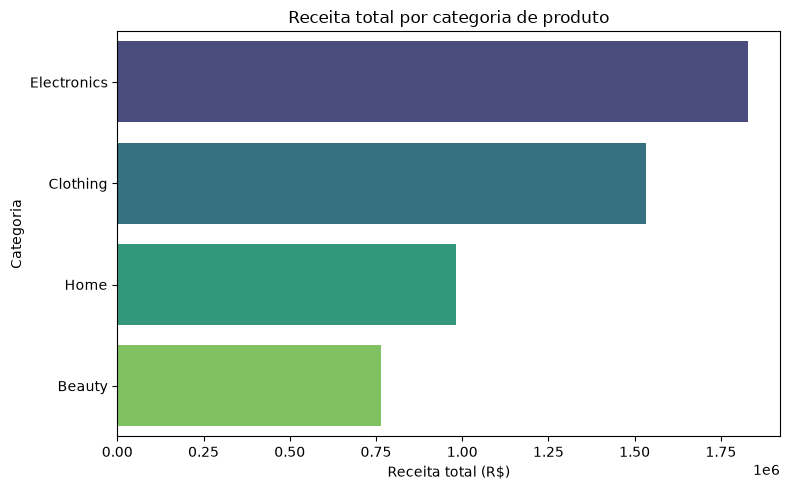

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

receita_categoria = df.groupby('product_category')['total_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=receita_categoria.values, y=receita_categoria.index, palette='viridis')
plt.title('Receita total por categoria de produto')
plt.xlabel('Receita total (R$)')
plt.ylabel('Categoria')
plt.tight_layout()
plt.savefig('../images/receita_por_categoria.png', dpi=150)
plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_37036\409129619.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prazo_regiao.index, y=prazo_regiao.values, palette='mako')


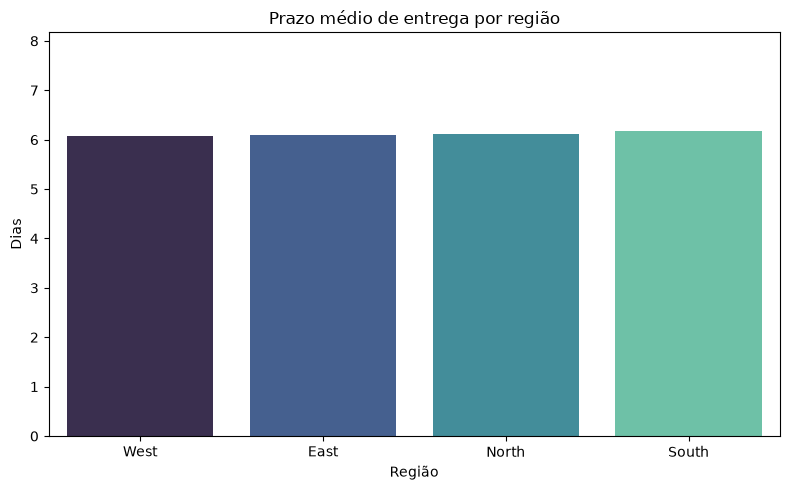

In [14]:
prazo_regiao = df.groupby('region')['delivery_days'].mean().sort_values()

plt.figure(figsize=(8, 5))
sns.barplot(x=prazo_regiao.index, y=prazo_regiao.values, palette='mako')
plt.title('Prazo médio de entrega por região')
plt.xlabel('Região')
plt.ylabel('Dias')
plt.ylim(0, prazo_regiao.max() + 2)  # ajuda a visualizar que a diferença é pequena
plt.tight_layout()
plt.savefig('../images/prazo_entrega_por_regiao.png', dpi=150)
plt.show()

C:\Users\julia\AppData\Local\Temp\ipykernel_37036\506513907.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=desconto_pagamento.index, y=desconto_pagamento.values, palette='flare')


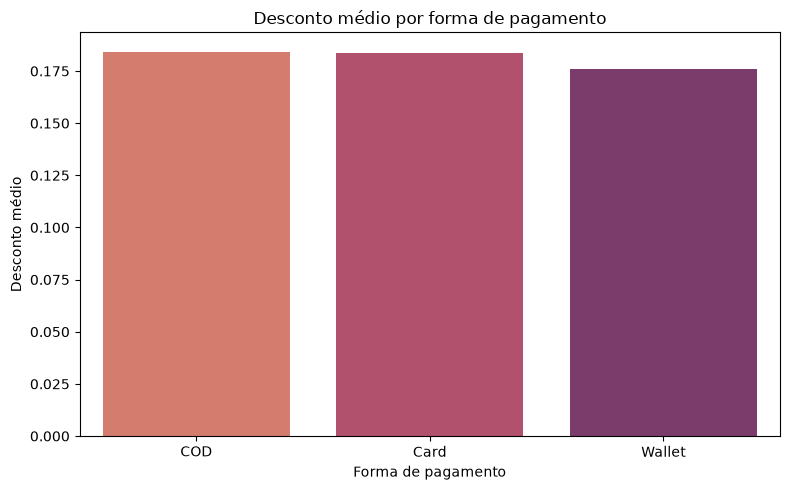

In [15]:
desconto_pagamento = df.groupby('payment_method')['discount'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=desconto_pagamento.index, y=desconto_pagamento.values, palette='flare')
plt.title('Desconto médio por forma de pagamento')
plt.xlabel('Forma de pagamento')
plt.ylabel('Desconto médio')
plt.tight_layout()
plt.savefig('../images/desconto_por_pagamento.png', dpi=150)
plt.show()

In [12]:
import os
os.makedirs('../images', exist_ok=True)

In [9]:
# conferir se os tipos de dado estão certos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5000 non-null   int64         
 1   order_date        5000 non-null   datetime64[us]
 2   customer_id       5000 non-null   int64         
 3   product_category  5000 non-null   str           
 4   region            5000 non-null   str           
 5   quantity          5000 non-null   int64         
 6   unit_price        5000 non-null   float64       
 7   discount          4932 non-null   float64       
 8   payment_method    5000 non-null   str           
 9   delivery_days     5000 non-null   int64         
 10  total_value       5000 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(4), str(3)
memory usage: 429.8 KB
